In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
fundamental_data = pd.read_csv(r'../data/scrapped/fundamental_data.csv')

# Reconstruct combined market data from per-stock files (market_data_raw.csv no longer exists)
TICKERS = ['RELIANCE', 'HDFCBANK', 'INFY', 'M&M', 'BHARTIARTL', 'HINDUNILVR']
OHLCV_MAP = {'open': 'Open', 'high': 'High', 'low': 'Low', 'close': 'Close', 'volume': 'Volume'}

dfs = []
for t in TICKERS:
    path = f'../data/scrapped/{t}/{t}_Market_Data.csv'
    tmp = pd.read_csv(path, parse_dates=['Date'], index_col='Date')[list(OHLCV_MAP.keys())].rename(columns=OHLCV_MAP)
    tmp.columns = pd.MultiIndex.from_product([[f'{t}.NS'], tmp.columns])
    dfs.append(tmp)

market_data_raw = pd.concat(dfs, axis=1)
print(market_data_raw.shape)
market_data_raw.head()

(1486, 30)


RELIANCE.NS                                                \
                  Open        High         Low       Close    Volume   
Date                                                                   
2020-01-01  679.081936  683.152852  673.490062  675.324158  14004468   
2020-01-02  676.397899  689.348791  676.397899  686.821228  17710316   
2020-01-03  685.792252  689.661895  681.318729  687.648804  20984698   
2020-01-06  679.976719  683.510767  670.134933  671.700684  24519177   
2020-01-07  679.529260  686.463273  677.068828  682.034485  16683622   

           HDFCBANK.NS                                                ...  \
                  Open        High         Low       Close    Volume  ...   
Date                                                                  ...   
2020-01-01  604.345327  606.192331  601.740595  605.529297   3673698  ...   
2020-01-02  605.718854  609.981145  605.718854  609.389160   6137166  ...   
2020-01-03  607.234269  608.560338  598.425547  600.698792  10855550  ...   
2020-01-06  596.720663  597.573144  585.354555  587.698792  10890186  ...   
2020-01-07  596.199746  602.143238  593.050375  597.004822  14724494  ...   

           BHARTIARTL.NS                                               \
                    Open        High         Low       Close   Volume   
Date                                                                    
2020-01-01    435.945225  440.199069  429.922956  433.316467  5154996   
2020-01-02    434.081200  439.147557  433.507665  435.132721  4933053   
2020-01-03    435.610705  438.956397  431.595869  435.037140  5154587   
2020-01-06    433.890018  437.283530  425.047803  429.827393  7538915   
2020-01-07    432.073800  435.228304  423.566142  425.477966  4353883   

           HINDUNILVR.NS                                                  
                    Open         High          Low        Close   Volume  
Date                                                                      
2020-01-01   1744.012553  1752.958546  1733.168952  1749.931396   543035  
2020-01-02   1753.049151  1764.434912  1744.012815  1751.287109   663275  
2020-01-03   1751.151288  1753.048896  1733.846685  1741.708252  1598825  
2020-01-06   1741.618130  1743.470623  1727.069651  1730.864868   683129  
2020-01-07   1734.298906  1744.916602  1733.169364  1735.609131   808935  

[5 rows x 30 columns]

In [3]:
fundamental_data.head()

,Ticker,Date,EPS,P/E Ratio,Debt-to-Equity,Revenue,Net Profit,ROE,ROA,Net Profit Margin,...,P/B Ratio,EV/EBITDA,Current Ratio,Free Cash Flow,Operating Cash Flow,Asset Turnover,Inventory Turnover,FCF Yield,Revenue Growth,Earnings Growth
0,RELIANCE,2024-06-30,11.19,34.599810,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RELIANCE,2024-09-30,12.24,30.038831,0.436297,2.315350e+12,1.656300e+11,0.080849,0.036500,0.071536,...,2.428721,18.173137,1.080522,NaN,NaN,0.510235,5.754209,NaN,NaN,0.093834
2,RELIANCE,2024-12-31,13.70,22.091512,NaN,2.399860e+12,1.854000e+11,NaN,NaN,0.077255,...,NaN,11.761683,NaN,NaN,NaN,NaN,NaN,NaN,0.03650,0.119281
3,RELIANCE,2025-03-31,NaN,NaN,0.438301,2.613880e+12,1.940700e+11,0.092064,0.039807,0.074246,...,2.002294,14.778499,1.100351,NaN,NaN,0.536147,7.158275,NaN,0.08918,NaN
4,RELIANCE,2025-06-30,19.95,18.729707,NaN,2.436320e+12,2.699400e+11,NaN,NaN,0.110798,...,NaN,11.444733,NaN,NaN,NaN,NaN,NaN,NaN,-0.06793,NaN


In [4]:
market_data_raw.head()

RELIANCE.NS                                                \
                  Open        High         Low       Close    Volume   
Date                                                                   
2020-01-01  679.081936  683.152852  673.490062  675.324158  14004468   
2020-01-02  676.397899  689.348791  676.397899  686.821228  17710316   
2020-01-03  685.792252  689.661895  681.318729  687.648804  20984698   
2020-01-06  679.976719  683.510767  670.134933  671.700684  24519177   
2020-01-07  679.529260  686.463273  677.068828  682.034485  16683622   

           HDFCBANK.NS                                                ...  \
                  Open        High         Low       Close    Volume  ...   
Date                                                                  ...   
2020-01-01  604.345327  606.192331  601.740595  605.529297   3673698  ...   
2020-01-02  605.718854  609.981145  605.718854  609.389160   6137166  ...   
2020-01-03  607.234269  608.560338  598.425547  600.698792  10855550  ...   
2020-01-06  596.720663  597.573144  585.354555  587.698792  10890186  ...   
2020-01-07  596.199746  602.143238  593.050375  597.004822  14724494  ...   

           BHARTIARTL.NS                                               \
                    Open        High         Low       Close   Volume   
Date                                                                    
2020-01-01    435.945225  440.199069  429.922956  433.316467  5154996   
2020-01-02    434.081200  439.147557  433.507665  435.132721  4933053   
2020-01-03    435.610705  438.956397  431.595869  435.037140  5154587   
2020-01-06    433.890018  437.283530  425.047803  429.827393  7538915   
2020-01-07    432.073800  435.228304  423.566142  425.477966  4353883   

           HINDUNILVR.NS                                                  
                    Open         High          Low        Close   Volume  
Date                                                                      
2020-01-01   1744.012553  1752.958546  1733.168952  1749.931396   543035  
2020-01-02   1753.049151  1764.434912  1744.012815  1751.287109   663275  
2020-01-03   1751.151288  1753.048896  1733.846685  1741.708252  1598825  
2020-01-06   1741.618130  1743.470623  1727.069651  1730.864868   683129  
2020-01-07   1734.298906  1744.916602  1733.169364  1735.609131   808935  

[5 rows x 30 columns]

# Cleaning market_data_raw.csv

In [5]:
# All 6 tickers present (M&M replaces TATAMOTORS); no empty columns to drop
print(market_data_raw.shape)
market_data_raw.head()

(1486, 30)


RELIANCE.NS                                                \
                  Open        High         Low       Close    Volume   
Date                                                                   
2020-01-01  679.081936  683.152852  673.490062  675.324158  14004468   
2020-01-02  676.397899  689.348791  676.397899  686.821228  17710316   
2020-01-03  685.792252  689.661895  681.318729  687.648804  20984698   
2020-01-06  679.976719  683.510767  670.134933  671.700684  24519177   
2020-01-07  679.529260  686.463273  677.068828  682.034485  16683622   

           HDFCBANK.NS                                                ...  \
                  Open        High         Low       Close    Volume  ...   
Date                                                                  ...   
2020-01-01  604.345327  606.192331  601.740595  605.529297   3673698  ...   
2020-01-02  605.718854  609.981145  605.718854  609.389160   6137166  ...   
2020-01-03  607.234269  608.560338  598.425547  600.698792  10855550  ...   
2020-01-06  596.720663  597.573144  585.354555  587.698792  10890186  ...   
2020-01-07  596.199746  602.143238  593.050375  597.004822  14724494  ...   

           BHARTIARTL.NS                                               \
                    Open        High         Low       Close   Volume   
Date                                                                    
2020-01-01    435.945225  440.199069  429.922956  433.316467  5154996   
2020-01-02    434.081200  439.147557  433.507665  435.132721  4933053   
2020-01-03    435.610705  438.956397  431.595869  435.037140  5154587   
2020-01-06    433.890018  437.283530  425.047803  429.827393  7538915   
2020-01-07    432.073800  435.228304  423.566142  425.477966  4353883   

           HINDUNILVR.NS                                                  
                    Open         High          Low        Close   Volume  
Date                                                                      
2020-01-01   1744.012553  1752.958546  1733.168952  1749.931396   543035  
2020-01-02   1753.049151  1764.434912  1744.012815  1751.287109   663275  
2020-01-03   1751.151288  1753.048896  1733.846685  1741.708252  1598825  
2020-01-06   1741.618130  1743.470623  1727.069651  1730.864868   683129  
2020-01-07   1734.298906  1744.916602  1733.169364  1735.609131   808935  

[5 rows x 30 columns]

In [6]:
market_data_raw.drop_duplicates(inplace = True)
print(market_data_raw.shape)
market_data_raw.head()


(1486, 30)


RELIANCE.NS                                                \
                  Open        High         Low       Close    Volume   
Date                                                                   
2020-01-01  679.081936  683.152852  673.490062  675.324158  14004468   
2020-01-02  676.397899  689.348791  676.397899  686.821228  17710316   
2020-01-03  685.792252  689.661895  681.318729  687.648804  20984698   
2020-01-06  679.976719  683.510767  670.134933  671.700684  24519177   
2020-01-07  679.529260  686.463273  677.068828  682.034485  16683622   

           HDFCBANK.NS                                                ...  \
                  Open        High         Low       Close    Volume  ...   
Date                                                                  ...   
2020-01-01  604.345327  606.192331  601.740595  605.529297   3673698  ...   
2020-01-02  605.718854  609.981145  605.718854  609.389160   6137166  ...   
2020-01-03  607.234269  608.560338  598.425547  600.698792  10855550  ...   
2020-01-06  596.720663  597.573144  585.354555  587.698792  10890186  ...   
2020-01-07  596.199746  602.143238  593.050375  597.004822  14724494  ...   

           BHARTIARTL.NS                                               \
                    Open        High         Low       Close   Volume   
Date                                                                    
2020-01-01    435.945225  440.199069  429.922956  433.316467  5154996   
2020-01-02    434.081200  439.147557  433.507665  435.132721  4933053   
2020-01-03    435.610705  438.956397  431.595869  435.037140  5154587   
2020-01-06    433.890018  437.283530  425.047803  429.827393  7538915   
2020-01-07    432.073800  435.228304  423.566142  425.477966  4353883   

           HINDUNILVR.NS                                                  
                    Open         High          Low        Close   Volume  
Date                                                                      
2020-01-01   1744.012553  1752.958546  1733.168952  1749.931396   543035  
2020-01-02   1753.049151  1764.434912  1744.012815  1751.287109   663275  
2020-01-03   1751.151288  1753.048896  1733.846685  1741.708252  1598825  
2020-01-06   1741.618130  1743.470623  1727.069651  1730.864868   683129  
2020-01-07   1734.298906  1744.916602  1733.169364  1735.609131   808935  

[5 rows x 30 columns]

In [7]:
missing_percent = market_data_raw.isnull().sum() * 100 / len(market_data_raw)
missing_percent

RELIANCE.NS    Open      0.0
               High      0.0
               Low       0.0
               Close     0.0
               Volume    0.0
HDFCBANK.NS    Open      0.0
               High      0.0
               Low       0.0
               Close     0.0
               Volume    0.0
INFY.NS        Open      0.0
               High      0.0
               Low       0.0
               Close     0.0
               Volume    0.0
M&M.NS         Open      0.0
               High      0.0
               Low       0.0
               Close     0.0
               Volume    0.0
BHARTIARTL.NS  Open      0.0
               High      0.0
               Low       0.0
               Close     0.0
               Volume    0.0
HINDUNILVR.NS  Open      0.0
               High      0.0
               Low       0.0
               Close     0.0
               Volume    0.0
dtype: float64

In [8]:
market_data_cleaned = market_data_raw.stack(level=0)
market_data_cleaned.head()

Open         High          Low        Close  \
Date                                                                           
2020-01-01 BHARTIARTL.NS   435.945225   440.199069   429.922956   433.316467   
           HDFCBANK.NS     604.345327   606.192331   601.740595   605.529297   
           HINDUNILVR.NS  1744.012553  1752.958546  1733.168952  1749.931396   
           INFY.NS         631.561499   635.857836   629.456284   633.151123   
           M&M.NS          506.213272   511.057849   503.031000   509.727936   

                           Volume  
Date                               
2020-01-01 BHARTIARTL.NS  5154996  
           HDFCBANK.NS    3673698  
           HINDUNILVR.NS   543035  
           INFY.NS        2112415  
           M&M.NS         2611808

In [9]:
market_data_cleaned = market_data_cleaned.reset_index()
market_data_cleaned = market_data_cleaned.rename(columns={'level_1': 'Ticker'})
market_data_cleaned['Date'] = pd.to_datetime(market_data_cleaned['Date'])
market_data_cleaned

,Date,Ticker,Open,High,Low,Close,Volume
0,2020-01-01,BHARTIARTL.NS,435.945225,440.199069,429.922956,433.316467,5154996
1,2020-01-01,HDFCBANK.NS,604.345327,606.192331,601.740595,605.529297,3673698
2,2020-01-01,HINDUNILVR.NS,1744.012553,1752.958546,1733.168952,1749.931396,543035
3,2020-01-01,INFY.NS,631.561499,635.857836,629.456284,633.151123,2112415
4,2020-01-01,M&M.NS,506.213272,511.057849,503.031000,509.727936,2611808
...,...,...,...,...,...,...,...
8911,2025-12-30,HDFCBANK.NS,990.200012,995.000000,982.200012,990.900024,33155849
8912,2025-12-30,HINDUNILVR.NS,2293.300049,2298.000000,2283.000000,2290.199951,1556717
8913,2025-12-30,INFY.NS,1647.000000,1647.900024,1616.800049,1621.599976,9395937
8914,2025-12-30,M&M.NS,3590.000000,3666.000000,3575.199951,3660.300049,2063179


In [10]:
market_data_cleaned.drop_duplicates(inplace=True)
market_data_cleaned

,Date,Ticker,Open,High,Low,Close,Volume
0,2020-01-01,BHARTIARTL.NS,435.945225,440.199069,429.922956,433.316467,5154996
1,2020-01-01,HDFCBANK.NS,604.345327,606.192331,601.740595,605.529297,3673698
2,2020-01-01,HINDUNILVR.NS,1744.012553,1752.958546,1733.168952,1749.931396,543035
3,2020-01-01,INFY.NS,631.561499,635.857836,629.456284,633.151123,2112415
4,2020-01-01,M&M.NS,506.213272,511.057849,503.031000,509.727936,2611808
...,...,...,...,...,...,...,...
8911,2025-12-30,HDFCBANK.NS,990.200012,995.000000,982.200012,990.900024,33155849
8912,2025-12-30,HINDUNILVR.NS,2293.300049,2298.000000,2283.000000,2290.199951,1556717
8913,2025-12-30,INFY.NS,1647.000000,1647.900024,1616.800049,1621.599976,9395937
8914,2025-12-30,M&M.NS,3590.000000,3666.000000,3575.199951,3660.300049,2063179


In [11]:
market_data_cleaned.to_csv(r'../data/processed/market_data_cleaned.csv')

# Cleaning fundamental_data.csv

In [12]:
# Cleaning fundamental_data

missing_percent = fundamental_data.isnull().sum() * 100 / len(fundamental_data)
missing_percent

Ticker                  0.000000
Date                    0.000000
EPS                    25.806452
P/E Ratio              25.806452
Debt-to-Equity         38.709677
Revenue                19.354839
Net Profit             19.354839
ROE                    41.935484
ROA                    41.935484
Net Profit Margin      19.354839
Operating Margin       35.483871
P/B Ratio              38.709677
EV/EBITDA              32.258065
Current Ratio          54.838710
Free Cash Flow         74.193548
Operating Cash Flow    74.193548
Asset Turnover         41.935484
Inventory Turnover     80.645161
FCF Yield              74.193548
Revenue Growth         38.709677
Earnings Growth        64.516129
dtype: float64

In [13]:
cols = missing_percent[missing_percent > 50].index
fundamental_data.drop(columns = cols, inplace = True)
fundamental_data.head()

,Ticker,Date,EPS,P/E Ratio,Debt-to-Equity,Revenue,Net Profit,ROE,ROA,Net Profit Margin,Operating Margin,P/B Ratio,EV/EBITDA,Asset Turnover,Revenue Growth
0,RELIANCE,2024-06-30,11.19,34.599810,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RELIANCE,2024-09-30,12.24,30.038831,0.436297,2.315350e+12,1.656300e+11,0.080849,0.036500,0.071536,0.134122,2.428721,18.173137,0.510235,NaN
2,RELIANCE,2024-12-31,13.70,22.091512,NaN,2.399860e+12,1.854000e+11,NaN,NaN,0.077255,0.145100,NaN,11.761683,NaN,0.03650
3,RELIANCE,2025-03-31,NaN,NaN,0.438301,2.613880e+12,1.940700e+11,0.092064,0.039807,0.074246,0.126670,2.002294,14.778499,0.536147,0.08918
4,RELIANCE,2025-06-30,19.95,18.729707,NaN,2.436320e+12,2.699400e+11,NaN,NaN,0.110798,0.181347,NaN,11.444733,NaN,-0.06793


In [14]:
fundamental_data['Date'] = pd.to_datetime(fundamental_data['Date'])
fundamental_data.sort_values(by = 'Ticker')
fundamental_data.head()

,Ticker,Date,EPS,P/E Ratio,Debt-to-Equity,Revenue,Net Profit,ROE,ROA,Net Profit Margin,Operating Margin,P/B Ratio,EV/EBITDA,Asset Turnover,Revenue Growth
0,RELIANCE,2024-06-30,11.19,34.599810,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RELIANCE,2024-09-30,12.24,30.038831,0.436297,2.315350e+12,1.656300e+11,0.080849,0.036500,0.071536,0.134122,2.428721,18.173137,0.510235,NaN
2,RELIANCE,2024-12-31,13.70,22.091512,NaN,2.399860e+12,1.854000e+11,NaN,NaN,0.077255,0.145100,NaN,11.761683,NaN,0.03650
3,RELIANCE,2025-03-31,NaN,NaN,0.438301,2.613880e+12,1.940700e+11,0.092064,0.039807,0.074246,0.126670,2.002294,14.778499,0.536147,0.08918
4,RELIANCE,2025-06-30,19.95,18.729707,NaN,2.436320e+12,2.699400e+11,NaN,NaN,0.110798,0.181347,NaN,11.444733,NaN,-0.06793


In [15]:
fundamental_data = fundamental_data.fillna(fundamental_data.median(numeric_only=True))
fundamental_data.head() 

,Ticker,Date,EPS,P/E Ratio,Debt-to-Equity,Revenue,Net Profit,ROE,ROA,Net Profit Margin,Operating Margin,P/B Ratio,EV/EBITDA,Asset Turnover,Revenue Growth
0,RELIANCE,2024-06-30,11.19,34.599810,0.954306,4.512930e+11,6.630500e+10,0.199114,0.065953,0.163732,0.225740,9.254817,24.219855,0.447192,0.033135
1,RELIANCE,2024-09-30,12.24,30.038831,0.436297,2.315350e+12,1.656300e+11,0.080849,0.036500,0.071536,0.134122,2.428721,18.173137,0.510235,0.033135
2,RELIANCE,2024-12-31,13.70,22.091512,0.954306,2.399860e+12,1.854000e+11,0.199114,0.065953,0.077255,0.145100,9.254817,11.761683,0.447192,0.036500
3,RELIANCE,2025-03-31,11.11,46.013988,0.438301,2.613880e+12,1.940700e+11,0.092064,0.039807,0.074246,0.126670,2.002294,14.778499,0.536147,0.089180
4,RELIANCE,2025-06-30,19.95,18.729707,0.954306,2.436320e+12,2.699400e+11,0.199114,0.065953,0.110798,0.181347,9.254817,11.444733,0.447192,-0.067930


In [16]:
fundamental_data

,Ticker,Date,EPS,P/E Ratio,Debt-to-Equity,Revenue,Net Profit,ROE,ROA,Net Profit Margin,Operating Margin,P/B Ratio,EV/EBITDA,Asset Turnover,Revenue Growth
0,RELIANCE,2024-06-30,11.190,34.599810,0.954306,4.512930e+11,6.630500e+10,0.199114,0.065953,0.163732,0.225740,9.254817,24.219855,0.447192,0.033135
1,RELIANCE,2024-09-30,12.240,30.038831,0.436297,2.315350e+12,1.656300e+11,0.080849,0.036500,0.071536,0.134122,2.428721,18.173137,0.510235,0.033135
2,RELIANCE,2024-12-31,13.700,22.091512,0.954306,2.399860e+12,1.854000e+11,0.199114,0.065953,0.077255,0.145100,9.254817,11.761683,0.447192,0.036500
3,RELIANCE,2025-03-31,11.110,46.013988,0.438301,2.613880e+12,1.940700e+11,0.092064,0.039807,0.074246,0.126670,2.002294,14.778499,0.536147,0.089180
4,RELIANCE,2025-06-30,19.950,18.729707,0.954306,2.436320e+12,2.699400e+11,0.199114,0.065953,0.110798,0.181347,9.254817,11.444733,0.447192,-0.067930
5,RELIANCE,2025-09-30,11.110,46.013988,0.954306,4.512930e+11,6.630500e+10,0.199114,0.065953,0.163732,0.225740,9.254817,24.219855,0.447192,0.033135
6,RELIANCE,2025-12-31,13.780,28.490566,0.954306,2.649050e+12,1.864500e+11,0.199114,0.065953,0.070384,0.137068,9.254817,14.631916,0.447192,0.033135
7,HDFCBANK,2024-06-30,10.835,19.409992,1.415097,7.241699e+11,1.647485e+11,0.138492,0.016448,0.227500,0.225740,2.720442,24.219855,0.072299,0.033135
8,HDFCBANK,2024-09-30,11.110,46.013988,1.043601,1.955545e+11,1.738105e+11,0.095707,0.015212,0.888808,0.225740,1.810045,24.219855,0.017115,-0.729960
9,HDFCBANK,2024-12-31,23.110,9.461305,1.301248,6.527966e+11,1.765661e+11,0.140637,0.016704,0.270476,0.225740,2.679941,24.219855,0.061757,2.338182


In [17]:
fundamental_data = fundamental_data.drop_duplicates()
fundamental_data

,Ticker,Date,EPS,P/E Ratio,Debt-to-Equity,Revenue,Net Profit,ROE,ROA,Net Profit Margin,Operating Margin,P/B Ratio,EV/EBITDA,Asset Turnover,Revenue Growth
0,RELIANCE,2024-06-30,11.190,34.599810,0.954306,4.512930e+11,6.630500e+10,0.199114,0.065953,0.163732,0.225740,9.254817,24.219855,0.447192,0.033135
1,RELIANCE,2024-09-30,12.240,30.038831,0.436297,2.315350e+12,1.656300e+11,0.080849,0.036500,0.071536,0.134122,2.428721,18.173137,0.510235,0.033135
2,RELIANCE,2024-12-31,13.700,22.091512,0.954306,2.399860e+12,1.854000e+11,0.199114,0.065953,0.077255,0.145100,9.254817,11.761683,0.447192,0.036500
3,RELIANCE,2025-03-31,11.110,46.013988,0.438301,2.613880e+12,1.940700e+11,0.092064,0.039807,0.074246,0.126670,2.002294,14.778499,0.536147,0.089180
4,RELIANCE,2025-06-30,19.950,18.729707,0.954306,2.436320e+12,2.699400e+11,0.199114,0.065953,0.110798,0.181347,9.254817,11.444733,0.447192,-0.067930
5,RELIANCE,2025-09-30,11.110,46.013988,0.954306,4.512930e+11,6.630500e+10,0.199114,0.065953,0.163732,0.225740,9.254817,24.219855,0.447192,0.033135
6,RELIANCE,2025-12-31,13.780,28.490566,0.954306,2.649050e+12,1.864500e+11,0.199114,0.065953,0.070384,0.137068,9.254817,14.631916,0.447192,0.033135
7,HDFCBANK,2024-06-30,10.835,19.409992,1.415097,7.241699e+11,1.647485e+11,0.138492,0.016448,0.227500,0.225740,2.720442,24.219855,0.072299,0.033135
8,HDFCBANK,2024-09-30,11.110,46.013988,1.043601,1.955545e+11,1.738105e+11,0.095707,0.015212,0.888808,0.225740,1.810045,24.219855,0.017115,-0.729960
9,HDFCBANK,2024-12-31,23.110,9.461305,1.301248,6.527966e+11,1.765661e+11,0.140637,0.016704,0.270476,0.225740,2.679941,24.219855,0.061757,2.338182


In [18]:
fundamental_data.to_csv (r'../data/processed/fundamental_data.csv', index = False)

# Visualising the Data

In [19]:
market_data_cleaned['Date'] = pd.to_datetime(market_data_cleaned['Date'])
fundamental_data['Date'] = pd.to_datetime(fundamental_data['Date'])

market_data_cleaned = market_data_cleaned.sort_values('Date')
fundamental_data = fundamental_data.sort_values('Date')

In [20]:
# Match tickers: strip .NS suffix so market Ticker aligns with fundamental Ticker
market_data_cleaned['Ticker_clean'] = market_data_cleaned['Ticker'].str.replace(r'\.NS$', '', regex=True)

df = pd.merge(
    market_data_cleaned,
    fundamental_data.rename(columns={'Ticker': 'Ticker_clean'}),
    on=['Date', 'Ticker_clean'],
    how='left'
)

df = df.sort_values(['Ticker_clean', 'Date']).reset_index(drop=True)

# Per-ticker forward-fill: propagate quarterly fundamentals to daily rows within each stock
fund_cols = [c for c in fundamental_data.columns if c not in ['Ticker', 'Date']]
df[fund_cols] = df.groupby('Ticker_clean')[fund_cols].transform(lambda x: x.ffill())

print("Final Shape:", df.shape)
df.head()

Final Shape: (8916, 21)


,Date,Ticker,Open,High,Low,Close,Volume,Ticker_clean,EPS,P/E Ratio,...,Revenue,Net Profit,ROE,ROA,Net Profit Margin,Operating Margin,P/B Ratio,EV/EBITDA,Asset Turnover,Revenue Growth
0,2020-01-01,BHARTIARTL.NS,435.945225,440.199069,429.922956,433.316467,5154996,BHARTIARTL,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-02,BHARTIARTL.NS,434.081200,439.147557,433.507665,435.132721,4933053,BHARTIARTL,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-03,BHARTIARTL.NS,435.610705,438.956397,431.595869,435.037140,5154587,BHARTIARTL,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-01-06,BHARTIARTL.NS,433.890018,437.283530,425.047803,429.827393,7538915,BHARTIARTL,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-07,BHARTIARTL.NS,432.073800,435.228304,423.566142,425.477966,4353883,BHARTIARTL,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


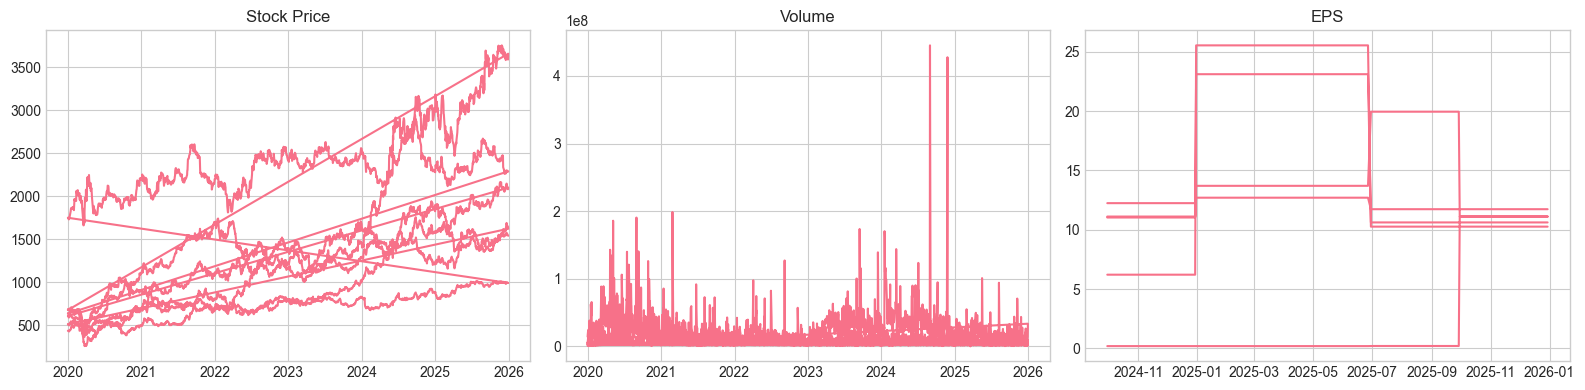

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

fig, axes = plt.subplots(1, 3, figsize=(16,4))

# Price
axes[0].plot(df['Date'], df['Close'])
axes[0].set_title("Stock Price")

# Volume
axes[1].plot(df['Date'], df['Volume'])
axes[1].set_title("Volume")

# Pick first numeric fundamental column safely
fund_numeric_cols = df.select_dtypes(include='number').columns.tolist()
fund_numeric_cols = [c for c in fund_numeric_cols if c not in ['Open','High','Low','Close','Volume']]

if len(fund_numeric_cols) > 0:
    axes[2].plot(df['Date'], df[fund_numeric_cols[0]])
    axes[2].set_title(fund_numeric_cols[0])

plt.tight_layout()
plt.show()

In [22]:
def create_technical_features(df):
    df = df.copy()
    eps = 1e-9

    df['Buying_Pressure']  = (df['Close'] - df['Low'])  / (df['High'] - df['Low'] + eps)
    df['Selling_Pressure'] = (df['High'] - df['Close']) / (df['High'] - df['Low'] + eps)

    for window in [5, 10, 20, 50]:
        df[f'SMA_{window}'] = df['Close'].rolling(window).mean()

    for span in [12, 26]:
        df[f'EMA_{span}'] = df['Close'].ewm(span=span, adjust=False).mean()

    df['MACD'] = df['EMA_12'] - df['EMA_26']
    df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

    delta = df['Close'].diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / (loss + 1e-9)
    df['RSI_14'] = 100 - (100 / (1 + rs))

    df['BB_middle'] = df['Close'].rolling(20).mean()
    df['BB_std'] = df['Close'].rolling(20).std()
    df['BB_upper'] = df['BB_middle'] + 2 * df['BB_std']
    df['BB_lower'] = df['BB_middle'] - 2 * df['BB_std']

    df['return_pct'] = df['Close'].pct_change() * 100
    for lag in [1,2,3,5]:
        df[f'return_lag{lag}'] = df['return_pct'].shift(lag)
        df[f'volume_lag{lag}'] = df['Volume'].shift(lag)

    return df

# Apply per-ticker to prevent rolling/lag features crossing stock boundaries
df = df.groupby('Ticker_clean', group_keys=False).apply(create_technical_features).reset_index(drop=True)

df.head()

,Date,Ticker,Open,High,Low,Close,Volume,Ticker_clean,EPS,P/E Ratio,...,BB_lower,return_pct,return_lag1,volume_lag1,return_lag2,volume_lag2,return_lag3,volume_lag3,return_lag5,volume_lag5
0,2020-01-01,BHARTIARTL.NS,435.945225,440.199069,429.922956,433.316467,5154996,BHARTIARTL,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-02,BHARTIARTL.NS,434.081200,439.147557,433.507665,435.132721,4933053,BHARTIARTL,NaN,NaN,...,NaN,0.419152,NaN,5154996.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-03,BHARTIARTL.NS,435.610705,438.956397,431.595869,435.037140,5154587,BHARTIARTL,NaN,NaN,...,NaN,-0.021966,0.419152,4933053.0,NaN,5154996.0,NaN,NaN,NaN,NaN
3,2020-01-06,BHARTIARTL.NS,433.890018,437.283530,425.047803,429.827393,7538915,BHARTIARTL,NaN,NaN,...,NaN,-1.197541,-0.021966,5154587.0,0.419152,4933053.0,NaN,5154996.0,NaN,NaN
4,2020-01-07,BHARTIARTL.NS,432.073800,435.228304,423.566142,425.477966,4353883,BHARTIARTL,NaN,NaN,...,NaN,-1.011901,-1.197541,7538915.0,-0.021966,5154587.0,0.419152,4933053.0,NaN,NaN


In [23]:
# Compute next-day return per-ticker to prevent cross-stock boundary contamination
df['Target'] = df.groupby('Ticker_clean')['Close'].transform(
    lambda x: x.pct_change().shift(-1) * 100
)

In [24]:
df = df.dropna()

numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
# Exclude both 'Target' (capital T) and 'target' (lowercase) to prevent target leakage
features = [c for c in numeric_cols if c not in ['Target', 'target']]

print("Total Features:", len(features))

Total Features: 42


In [25]:
from sklearn.feature_selection import mutual_info_regression

X = df[features]
y = df['Target']

mi_scores = mutual_info_regression(X, y, random_state=42)

mi_df = pd.DataFrame({
    'Feature': features,
    'MI Score': mi_scores
}).sort_values(by='MI Score', ascending=False)

mi_df.head(20)

,Feature,MI Score
2,Low,0.075169
1,High,0.070344
20,SMA_5,0.061021
0,Open,0.048662
3,Close,0.047387
21,SMA_10,0.040957
23,SMA_50,0.034793
25,EMA_26,0.029274
32,BB_lower,0.028337
38,return_lag3,0.024840


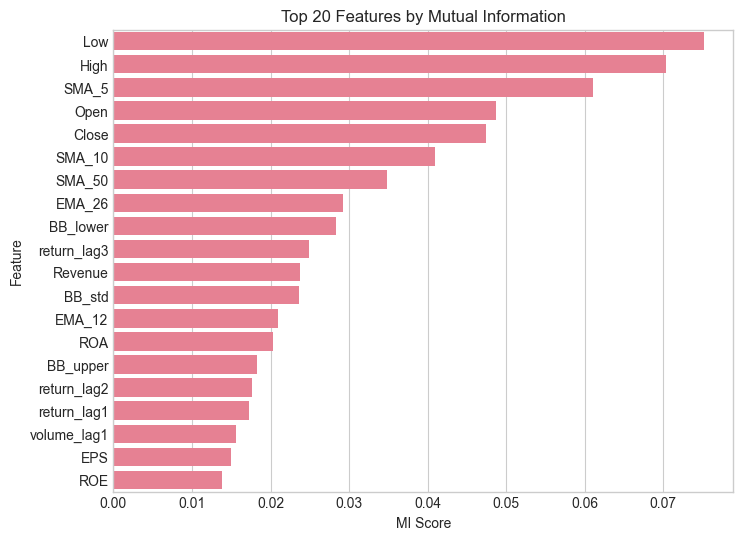

In [26]:
plt.figure(figsize=(8,6))
sns.barplot(data=mi_df.head(20), x='MI Score', y='Feature')
plt.title("Top 20 Features by Mutual Information")
plt.show()

In [27]:
print(market_data_cleaned.columns)

Index(['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume',
       'Ticker_clean'],
      dtype='object')
